# An Unsupervised Trading Strategy on the S&P 500

The idea is simple to state. Every month I group the S&P 500 by what its stocks have recently been doing, follow the group with the strongest momentum into the next month, and let a mean-variance optimizer decide how much to hold in each name. Then I check whether any of that beat simply holding the index — both the cap-weighted version (SPY) and the equal-weighted version (RSP), since an active rotation like this really ought to be measured against equal weight.

The pieces: pull the data, build a set of technical and factor features, roll everything up to a monthly panel, standardize and cluster the cross-section with K-means, follow the highest-momentum cluster, size it with a max-Sharpe optimizer net of trading costs, and backtest.

Everything downloaded is cached under `data_cache/`, so the first run pulls from the internet and every run after reads from disk.

In [1]:
import os
import re
import io
import datetime as dt

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

import yfinance as yf
import pandas_datareader.data as web
import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from pypfopt import EfficientFrontier, risk_models, expected_returns

import warnings
warnings.filterwarnings("ignore")
plt.style.use("ggplot")

In [2]:
# A tiny cache so we only ever hit the network once per dataset.
CACHE_DIR = "data_cache"
os.makedirs(CACHE_DIR, exist_ok=True)

def cached(name, fetch):
    path = os.path.join(CACHE_DIR, re.sub(r"[^A-Za-z0-9._-]+", "_", name) + ".pkl")
    if os.path.exists(path):
        print(f"loaded '{name}' from cache")
        return pd.read_pickle(path)
    print(f"downloading '{name}' ...")
    obj = fetch()
    pd.to_pickle(obj, path)
    return obj

## The universe and the prices

I take the companies currently in the S&P 500 straight from Wikipedia and pull ten years of daily bars from Yahoo.

In [3]:
def sp500_symbols():
    html = requests.get(
        "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies",
        headers={"User-Agent": "Mozilla/5.0"}, timeout=30).text
    table = pd.read_html(io.StringIO(html), match="Symbol")[0]
    return table["Symbol"].str.replace(".", "-", regex=False).unique().tolist()

symbols = cached("sp500_symbols", sp500_symbols)
print(len(symbols), "tickers")

loaded 'sp500_symbols' from cache
503 tickers


In [4]:
START, END = "2015-01-01", "2025-11-09"

def download_prices():
    raw = yf.download(symbols, start=START, end=END, auto_adjust=True)
    panel = raw.stack(level=1)                       # (date, ticker) rows, OHLCV columns
    panel.index = panel.index.set_names(["date", "symbol"])
    panel.columns = panel.columns.str.lower()
    return panel.sort_index()

prices = cached(f"prices_{START}_{END}", download_prices)
prices.tail()

loaded 'prices_2015-01-01_2025-11-09' from cache


Price              adj close       close        high         low        open  \
date       symbol                                                              
2025-11-07 XYZ           NaN   65.449997   66.739998   61.360001   61.360001   
           YUM           NaN  147.016815  147.302733  145.636567  146.277393   
           ZBH           NaN   87.793060   89.439804   86.731608   88.289066   
           ZBRA          NaN  259.540009  259.760010  252.139999  255.800003   
           ZTS           NaN  118.384987  118.414523  115.450965  117.715477   

Price                  volume  
date       symbol              
2025-11-07 XYZ     21402400.0  
           YUM      2415500.0  
           ZBH      2628200.0  
           ZBRA      777800.0  
           ZTS      5808800.0

## Features

 Garman–Klass volatility (which uses the whole day's range, not just closes), RSI, Bollinger bands on the log price, a standardized ATR, and MACD. Dollar volume tags along only to decide which names are liquid enough to trade.

In [5]:
px = prices.copy()

# garman-klass volatility
px["gk_vol"] = (((np.log(px["high"]) - np.log(px["low"])) ** 2) / 2
                - (2 * np.log(2) - 1) * (np.log(px["close"]) - np.log(px["open"])) ** 2)

# wilder rsi
def rsi(close, n=20):
    change = close.diff()
    gain = change.clip(lower=0).ewm(alpha=1 / n, min_periods=n, adjust=False).mean()
    loss = (-change).clip(lower=0).ewm(alpha=1 / n, min_periods=n, adjust=False).mean()
    return 100 - 100 / (1 + gain / loss)

px["rsi"] = px.groupby(level="symbol")["close"].transform(rsi)

# bollinger bands on the log price
log_close = np.log1p(px["close"]).groupby(level="symbol")
mid = log_close.transform(lambda s: s.rolling(20).mean())
sd = log_close.transform(lambda s: s.rolling(20).std())
px["bb_low"], px["bb_mid"], px["bb_high"] = mid - 2 * sd, mid, mid + 2 * sd

# average true range, standardized per name
prev_close = px.groupby(level="symbol")["close"].shift()
true_range = pd.concat([px["high"] - px["low"],
                        (px["high"] - prev_close).abs(),
                        (px["low"] - prev_close).abs()], axis=1).max(axis=1)
atr = true_range.groupby(level="symbol").transform(lambda s: s.rolling(14).mean())
px["atr"] = atr.groupby(level="symbol").transform(lambda s: (s - s.mean()) / s.std())

# macd, standardized per name
macd = px.groupby(level="symbol")["close"].transform(
    lambda s: s.ewm(span=12, adjust=False).mean() - s.ewm(span=26, adjust=False).mean())
px["macd"] = macd.groupby(level="symbol").transform(lambda s: (s - s.mean()) / s.std())

# dollar volume in millions, for the liquidity screen
px["dollar_volume"] = px["close"] * px["volume"] / 1e6

px[["rsi", "bb_mid", "atr", "macd", "gk_vol"]].tail()

Price                    rsi    bb_mid       atr      macd    gk_vol
date       symbol                                                   
2025-11-07 XYZ     35.176222  4.335631 -0.168290 -0.430232  0.001923
           YUM     55.273185  4.964698  2.046767 -0.194546  0.000055
           ZBH     34.345267  4.596900  0.996061 -1.001405  0.000460
           ZBRA    37.963618  5.651362  1.184410 -1.584403  0.000362
           ZTS     22.849422  4.928418  0.906066 -2.652672  0.000309

## Down to a monthly panel

Daily bars are noisy and I only rebalance monthly, so I collapse everything to month-end: the last reading for each signal, and the month's average for dollar volume. Anything with a gap gets dropped here.

In [6]:
feature_cols = ["close", "gk_vol", "rsi", "bb_low", "bb_mid", "bb_high", "atr", "macd"]

by_month = px.groupby([pd.Grouper(level="symbol"),
                       pd.Grouper(level="date", freq="ME")])
monthly = by_month[feature_cols].last()
monthly["dollar_volume"] = by_month["dollar_volume"].mean()
monthly = monthly.reorder_levels(["date", "symbol"]).sort_index().dropna()

print(monthly.index.get_level_values("date").nunique(), "months,", len(monthly), "stock-months")
monthly.tail()

130 months, 62825 stock-months


Price                   close    gk_vol        rsi    bb_low    bb_mid  \
date       symbol                                                        
2025-11-30 XYZ      65.449997  0.001923  35.176222  4.244835  4.335631   
           YUM     147.016815  0.000055  55.273185  4.911893  4.964698   
           ZBH      87.793060  0.000460  34.345267  4.489964  4.596900   
           ZBRA    259.540009  0.000362  37.963618  5.517025  5.651362   
           ZTS     118.384987  0.000309  22.849422  4.784378  4.928418   

Price               bb_high       atr      macd  dollar_volume  
date       symbol                                               
2025-11-30 XYZ     4.426427 -0.168290 -0.430232     669.149510  
           YUM     5.017503  2.046767 -0.194546     511.437644  
           ZBH     4.703837  0.996061 -1.001405     396.259138  
           ZBRA    5.785699  1.184410 -1.584403     216.351298  
           ZTS     5.072459  0.906066 -2.652672     912.432633

## Keeping it tradable

Each month I only consider genuinely liquid names. 

In [7]:
monthly["dollar_volume"] = (monthly.groupby(level="symbol")["dollar_volume"]
                                   .transform(lambda s: s.rolling(12).mean()))
rank = monthly.groupby(level="date")["dollar_volume"].rank(ascending=False)
monthly = monthly[rank <= 150].drop(columns="dollar_volume")

print(len(monthly), "stock-months after the liquidity screen")

17850 stock-months after the liquidity screen


## Momentum

For each name I add trailing returns over a spread of horizons, winsorized so one violent month doesn't dominate. I also build the classic **12‑minus‑1 momentum** — the trailing twelve‑month return skipping the most recent month — which is the signal I'll actually use to pick which cluster to hold. Skipping the last month matters: recent returns tend to reverse, so leaving them out is what separates real momentum from short‑term mean reversion.

In [8]:
close_by_symbol = monthly.groupby(level="symbol")["close"]
for lag in [1, 2, 3, 6, 9, 12]:
    r = close_by_symbol.pct_change(lag)
    lo = r.groupby(level="symbol").transform(lambda s: s.quantile(0.005))
    hi = r.groupby(level="symbol").transform(lambda s: s.quantile(0.995))
    monthly[f"return_{lag}m"] = r.clip(lo, hi).add(1).pow(1 / lag).sub(1)

# 12-1 momentum: price twelve months ago to one month ago
monthly["mom_12_1"] = close_by_symbol.transform(lambda s: s.shift(1) / s.shift(12) - 1)

monthly[["mom_12_1", "return_12m"]].tail()

Price              mom_12_1  return_12m
date       symbol                      
2025-11-30 WDC     2.206939    0.109488
           WFC     0.160498    0.012017
           WMT     0.104503    0.009481
           XOM    -0.003652    0.001755
           XYZ    -0.142405   -0.024875

## Factor exposure

Alongside the price signals I attach each stock's rolling exposure to the Fama–French five factors, lagged one month so a name is only ever described by information I'd have had on the rebalance date.

In [9]:
factor_names = ["Mkt-RF", "SMB", "HML", "RMW", "CMA"]

ff_raw = cached("fama_french_5",
                lambda: web.DataReader("F-F_Research_Data_5_Factors_2x3", "famafrench", start=2015)[0])

ff = ff_raw[factor_names].div(100)
ff.index = pd.DatetimeIndex(ff.index.to_timestamp()).normalize() + pd.offsets.MonthEnd(0)
ff.index.name = "date"
ff = ff[~ff.index.duplicated()]

panel = monthly[["return_1m"]].join(ff, on="date")

def rolling_betas(g):
    window = min(24, len(g))
    if window < 6:
        return pd.DataFrame(np.nan, index=g.index, columns=factor_names)
    params = RollingOLS(g["return_1m"], sm.add_constant(g[factor_names]),
                        window=window, min_nobs=6).fit(params_only=True).params
    return params.reindex(columns=factor_names)

betas = panel.groupby(level="symbol", group_keys=False).apply(rolling_betas)
monthly = monthly.join(betas.groupby(level="symbol").shift())

monthly[factor_names].tail()

loaded 'fama_french_5' from cache


Mkt-RF       SMB       HML        RMW       CMA
date       symbol                                                   
2025-11-30 WDC     5.422310 -9.003309  6.069417 -27.583601 -9.009944
           WFC     0.977883 -0.097847  0.492144  -1.164791  0.129581
           WMT     0.649211  0.078130 -0.308168   0.655172 -0.740561
           XOM     0.258110 -0.376589  0.949107   0.335444  0.061066
           XYZ     2.174085  0.726270 -0.472917  -2.654645  0.327980

## Clustering the cross-section

 K-means measures distance across every feature at once, so if the features live on different scales — RSI runs 0–100, returns run around a tenth, betas near one, whichever has the biggest raw numbers quietly dominates and the clusters collapse onto that one axis. So before clustering I **standardize every feature within each month**, putting them all on the same footing.


In [10]:
cluster_features = ["gk_vol", "rsi", "bb_low", "bb_mid", "bb_high", "atr", "macd",
                    "return_1m", "return_2m", "return_3m", "return_6m", "return_9m",
                    "return_12m", "mom_12_1"] + factor_names

monthly = monthly.dropna(subset=cluster_features)

def cluster_and_select(m):
    x = StandardScaler().fit_transform(m[cluster_features].values)
    m = m.assign(cluster=KMeans(n_clusters=4, n_init=10, random_state=0).fit(x).labels_)
    winner = m.groupby("cluster")["mom_12_1"].mean().idxmax()      # strongest-momentum group
    m["is_pick"] = m["cluster"].eq(winner)
    return m[["cluster", "is_pick"]]

labels = pd.concat([cluster_and_select(m) for _, m in monthly.groupby(level="date")])
monthly[["cluster", "is_pick"]] = labels

print(len(monthly), "stock-months clustered;",
      int(monthly["is_pick"].sum()), "selected across all months")

12601 stock-months clustered; 1600 selected across all months


## A look at the clusters

Plotting a few recent months on momentum against RSI gives a feel for the split. The selected (high-momentum) cluster is highlighted; everything else is greyed out.

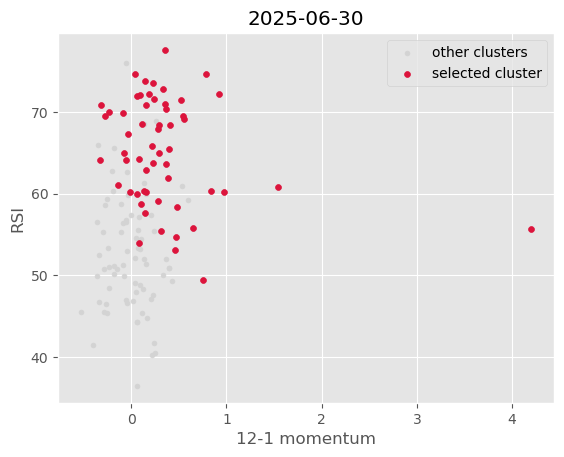

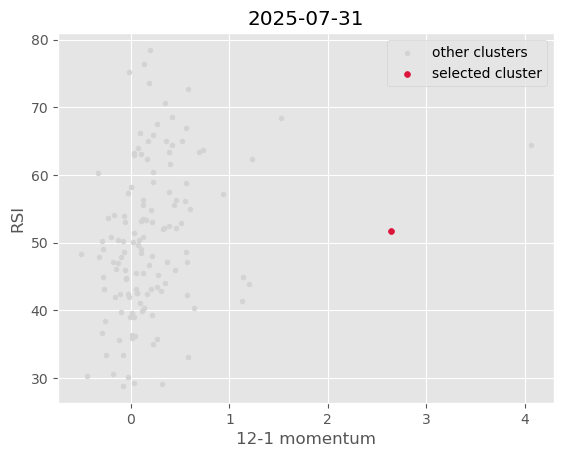

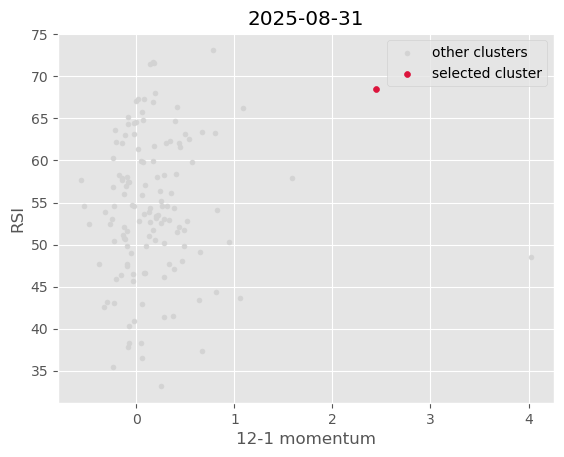

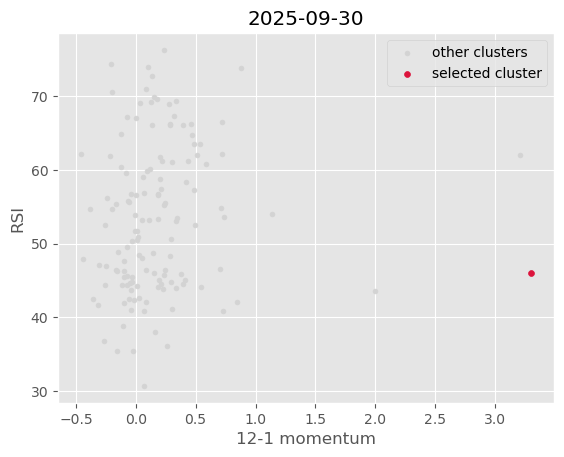

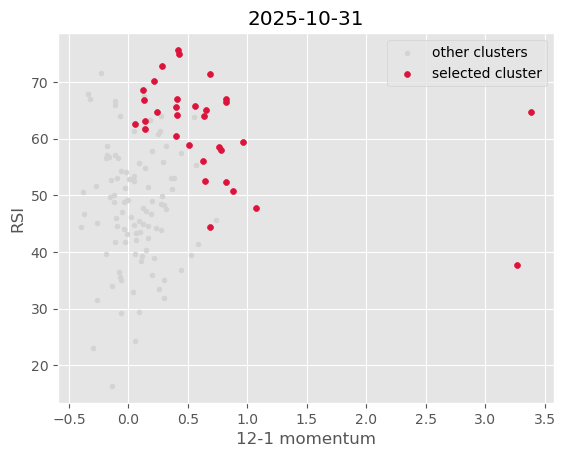

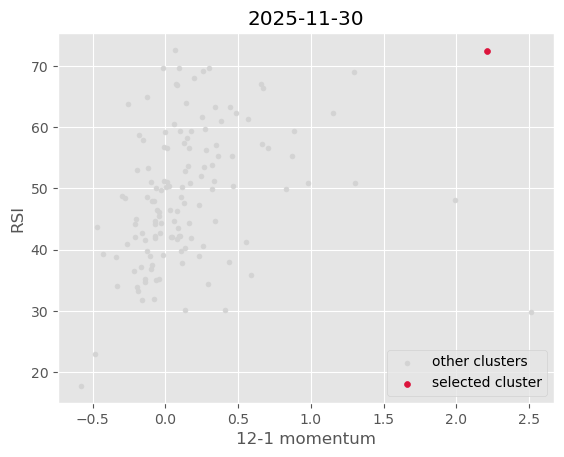

In [11]:
def show_clusters(month_slice, title):
    rest = month_slice[~month_slice["is_pick"]]
    pick = month_slice[month_slice["is_pick"]]
    plt.scatter(rest["mom_12_1"], rest["rsi"], s=12, color="lightgray", label="other clusters")
    plt.scatter(pick["mom_12_1"], pick["rsi"], s=18, color="crimson", label="selected cluster")
    plt.title(title)
    plt.xlabel("12-1 momentum")
    plt.ylabel("RSI")
    plt.legend()
    plt.show()

for date in monthly.index.get_level_values("date").unique()[-6:]:
    show_clusters(monthly.xs(date, level="date"), str(date.date()))

## Building the portfolio

I follow the selected cluster into the following month. At each rebalance the weights come from a max-Sharpe optimization on the trailing year of prices, capped at 10% a name; if that has no feasible solution, too few names, or a degenerate covariance, I hold the cluster equally weighted. I also charge a realistic trading cost: **ten basis points on the turnover** each time the book is rebalanced, so a strategy that churns pays for it.

In [12]:
close_wide = prices["close"].unstack("symbol").sort_index()
daily_returns = close_wide.pct_change()

COST_PER_TURNOVER = 0.0010   # 10 bps on the traded fraction each rebalance

def max_sharpe_weights(price_block):
    mu = expected_returns.mean_historical_return(price_block)
    cov = risk_models.sample_cov(price_block)
    ef = EfficientFrontier(mu, cov, weight_bounds=(0, 0.10))
    ef.max_sharpe()
    return pd.Series(ef.clean_weights())

selected = monthly[monthly["is_pick"]]
rebalance_dates = selected.index.get_level_values("date").unique()

strategy_daily = []
prev_weights = pd.Series(dtype=float)
equal_weight_months = 0
for d in rebalance_dates:
    names = [s for s in selected.xs(d, level="date").index if s in close_wide.columns]
    train = close_wide.loc[d - pd.DateOffset(months=12):d, names].dropna(axis=1)
    if train.shape[1] < 2:
        continue
    try:
        weights = max_sharpe_weights(train)
    except Exception:
        equal_weight_months += 1
        weights = pd.Series(1 / train.shape[1], index=train.columns)
    weights = weights[weights > 0]

    names_union = weights.index.union(prev_weights.index)
    turnover = (weights.reindex(names_union, fill_value=0)
                - prev_weights.reindex(names_union, fill_value=0)).abs().sum()
    cost = turnover * COST_PER_TURNOVER

    held = daily_returns.loc[d + pd.Timedelta(days=1):d + pd.offsets.MonthEnd(1),
                             weights.index].mul(weights, axis=1).sum(axis=1)
    if len(held):
        held.iloc[0] -= cost               # pay the rebalance cost up front
    strategy_daily.append(held)
    prev_weights = weights

strategy = pd.concat(strategy_daily).sort_index()
strategy = strategy[~strategy.index.duplicated()]

print(f"{len(rebalance_dates)} rebalances, {equal_weight_months} fell back to equal weight")

95 rebalances, 23 fell back to equal weight


## Against the index — cap-weighted and equal-weighted

Two benchmarks, both held from 2018: SPY for the familiar cap-weighted S&P 500, and RSP for the equal-weighted version.

In [13]:
def close_series(df):
    c = df["Close"]
    return c.iloc[:, 0] if isinstance(c, pd.DataFrame) else c

spy = cached("spy", lambda: yf.download("SPY", start="2018-01-01", end=dt.date.today(), auto_adjust=True))
rsp = cached("rsp", lambda: yf.download("RSP", start="2018-01-01", end=dt.date.today(), auto_adjust=True))

comparison = pd.DataFrame({
    "Strategy": strategy,
    "SPY (cap-weight)": close_series(spy).pct_change(),
    "RSP (equal-weight)": close_series(rsp).pct_change(),
}).dropna()
comparison.tail()

loaded 'spy' from cache
downloading 'rsp' ...


[*********************100%***********************]  1 of 1 completed


,Strategy,SPY (cap-weight),RSP (equal-weight)
2025-11-03,0.002594,0.001877,-0.002448
2025-11-04,-0.022906,-0.011854,-0.006614
2025-11-05,0.015381,0.003465,0.005853
2025-11-06,-0.004553,-0.010729,-0.007047
2025-11-07,-0.000413,0.000984,0.008387


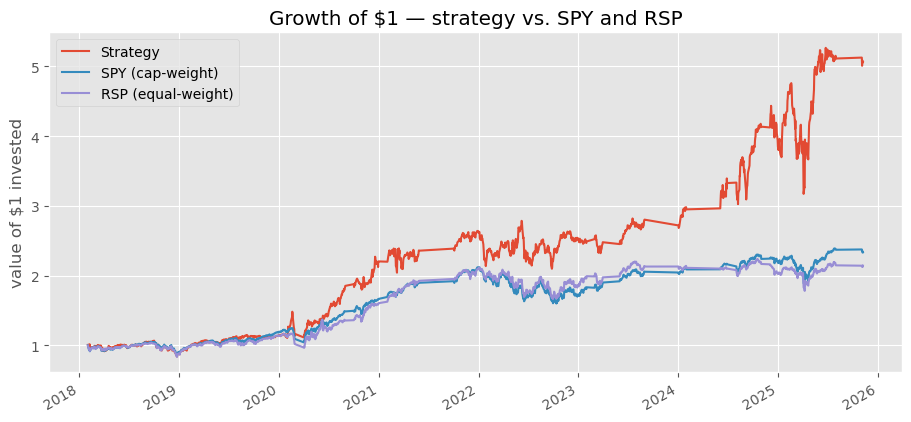

In [14]:
growth = (1 + comparison).cumprod()
growth.plot(figsize=(11, 5))
plt.title("Growth of $1 — strategy vs. SPY and RSP")
plt.ylabel("value of $1 invested")
plt.show()

## How it did

The numbers that matter: total and annualized return, volatility, Sharpe and Sortino, and the worst drawdown, for the strategy against both benchmarks. The last two rows are the strategy's alpha and beta to the cap-weighted market.

In [15]:
def performance(r, periods=252):
    total = (1 + r).prod() - 1
    cagr = (1 + total) ** (periods / len(r)) - 1
    vol = r.std() * np.sqrt(periods)
    sharpe = r.mean() / r.std() * np.sqrt(periods)
    downside = r[r < 0].std() * np.sqrt(periods)
    sortino = r.mean() * periods / downside
    curve = (1 + r).cumprod()
    max_drawdown = (curve / curve.cummax() - 1).min()
    return pd.Series({"Total return": total, "CAGR": cagr, "Volatility": vol,
                      "Sharpe": sharpe, "Sortino": sortino, "Max drawdown": max_drawdown})

results = pd.DataFrame({col: performance(comparison[col]) for col in comparison.columns})

capm = sm.OLS(comparison["Strategy"],
              sm.add_constant(comparison["SPY (cap-weight)"])).fit()
results.loc["Alpha (annual)", "Strategy"] = capm.params["const"] * 252
results.loc["Beta", "Strategy"] = capm.params.iloc[1]

results.round(3)

,Strategy,SPY (cap-weight),RSP (equal-weight)
Total return,4.060,1.331,1.142
CAGR,0.320,0.156,0.139
Volatility,0.301,0.186,0.187
Sharpe,1.071,0.873,0.793
Sortino,1.421,1.145,1.075
Max drawdown,-0.334,-0.245,-0.214
Alpha (annual),0.143,NaN,NaN
Beta,1.107,NaN,NaN
